# Student Management System with Data Science and DBSCAN
**Python for Data Science**

## 1. Setup and unique dataset

In [2]:
import warnings, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

N_STUDENTS = 300
SEED = 2026
CSV_FILE = "students_dataset.csv"

SUBJECTS = ["Python", "DataScience", "Maths", "DBMS"]
COLUMNS = ["StudentID", "Name", "Branch", "Semester", "Gender", "Attendance", "StudyHours",
           "Python", "DataScience", "Maths", "DBMS", "AssignmentScore", "Backlogs"]

In [3]:
students = pd.read_csv(CSV_FILE)[COLUMNS]
injected_ids = set()

print("Dataset shape:", students.shape)
display(students.head())

Dataset shape: (300, 13)


,StudentID,Name,Branch,Semester,Gender,Attendance,StudyHours,Python,DataScience,Maths,DBMS,AssignmentScore,Backlogs
0,1001,Anaya Desai,Computer,5,Female,84.5,3.8,99.0,89.0,83.0,82.0,79.6,0
1,1002,Meera Patel,Mechanical,6,Female,74.2,1.4,61.0,64.0,83.0,68.0,76.7,1
2,1003,Harsh Joshi,IT,6,Male,72.4,2.0,74.0,61.0,50.0,57.0,69.6,1
3,1004,Jay Vora,Electronics,4,Female,74.7,1.8,63.0,68.0,58.0,57.0,66.1,1
4,1005,Pooja Shah,Electrical,5,Male,75.3,2.4,58.0,73.0,58.0,65.0,63.4,0


## 2. Student Management System (CRUD with SQLite)

In [4]:
class StudentNotFound(Exception):
    pass

class StudentManager:
    def __init__(self, db="students.db"):
        self.conn = sqlite3.connect(db)

    def load(self, df):                                       # create the table from a DataFrame
        df.assign(Cluster=None).to_sql("students", self.conn, if_exists="replace", index=False)

    def add_student(self, student_id, **data):                # CREATE
        row = pd.DataFrame([{"StudentID": student_id, **data}])
        row.to_sql("students", self.conn, if_exists="append", index=False)

    def all_students(self, where="1=1", params=()):           # READ
        return pd.read_sql(f"SELECT * FROM students WHERE {where}", self.conn, params=params)

    def get_student(self, sid):
        df = self.all_students("StudentID = ?", (int(sid),))
        if df.empty:
            raise StudentNotFound(f"Student {sid} not found")
        return df.iloc[0]

    def search(self, name_part):
        return self.all_students("Name LIKE ?", (f"%{name_part}%",))

    def update_student(self, sid, **fields):                  # UPDATE
        self.get_student(sid)                                 # raises StudentNotFound if missing
        for column, value in fields.items():
            self.conn.execute(f"UPDATE students SET {column} = ? WHERE StudentID = ?", (value, int(sid)))
        self.conn.commit()

    def delete_student(self, sid):                            # DELETE
        self.get_student(sid)
        self.conn.execute("DELETE FROM students WHERE StudentID = ?", (int(sid),))
        self.conn.commit()

    def report_card(self, sid):
        s = self.get_student(sid)
        print(f"REPORT CARD | ID {int(s.StudentID)} | {s.Name} | {s.Branch}, Semester {int(s.Semester)}")
        for sub in SUBJECTS:
            print(f"  {sub:<12}{s[sub]:>5.0f}")
        print(f"  Average     {np.mean([s[x] for x in SUBJECTS]):>5.1f}")
        print(f"  Attendance {s.Attendance}% | Backlogs {s.Backlogs} | Group: {s.Cluster or 'not assigned yet'}")

sms = StudentManager()
sms.load(students)
print("Students stored in database:", len(sms.all_students()))

Students stored in database: 300


In [5]:
# ---- CRUD demo ----
print("CREATE: add student 9999")
sms.add_student(9999, Name="Test Student", Branch="Computer", Semester=5, Gender="Male", Attendance=88.0,
                StudyHours=2.5, Python=70, DataScience=75, Maths=68, DBMS=72, AssignmentScore=80, Backlogs=0)
display(sms.get_student(9999).to_frame().T)

print("READ / SEARCH: students named 'Test'")
display(sms.search("Test")[["StudentID", "Name", "Branch", "Semester"]])

print("UPDATE: change attendance and branch")
sms.update_student(9999, Attendance=92.5, Branch="IT")
sms.report_card(9999)

print("DELETE: remove student 9999")
sms.delete_student(9999)
try:
    sms.get_student(9999)
except StudentNotFound as e:
    print("Exception handled ->", e)
print("Total students now:", len(sms.all_students()))

CREATE: add student 9999


,StudentID,Name,Branch,Semester,Gender,Attendance,StudyHours,Python,DataScience,Maths,DBMS,AssignmentScore,Backlogs,Cluster
0,9999,Test Student,Computer,5,Male,88.0,2.5,70.0,75.0,68.0,72.0,80.0,0,None


READ / SEARCH: students named 'Test'


,StudentID,Name,Branch,Semester
0,9999,Test Student,Computer,5


UPDATE: change attendance and branch
REPORT CARD | ID 9999 | Test Student | IT, Semester 5
  Python         70
  DataScience    75
  Maths          68
  DBMS           72
  Average      71.2
  Attendance 92.5% | Backlogs 0 | Group: not assigned yet
DELETE: remove student 9999
Exception handled -> Student 9999 not found
Total students now: 300


## 3. Data cleaning and feature engineering

In [6]:
df = sms.all_students()
print("Missing values per column:")
print(df.isna().sum()[lambda s: s > 0])
print("Duplicate IDs:", df["StudentID"].duplicated().sum())

for col in ["AssignmentScore", "StudyHours"]:
    df[col] = df[col].fillna(df[col].median())

df["AvgMarks"] = df[SUBJECTS].mean(axis=1).round(1)
df["Result"] = np.where(df["AvgMarks"] >= 40, "Pass", "Fail")
display(df.describe().round(2).T)

Missing values per column:
StudyHours           9
AssignmentScore     12
Cluster            300
dtype: int64
Duplicate IDs: 0


,count,mean,std,min,25%,50%,75%,max
StudentID,300.0,1150.50,86.75,1001.0,1075.75,1150.50,1225.25,1300.0
Semester,300.0,4.49,1.13,3.0,3.00,5.00,6.00,6.0
Attendance,300.0,74.17,14.52,24.5,63.08,76.35,84.70,100.0
StudyHours,300.0,2.16,1.20,0.0,1.40,2.00,2.90,6.8
Python,300.0,59.24,17.36,12.0,46.75,60.50,72.00,99.0
DataScience,300.0,58.96,18.07,9.0,46.00,59.00,70.00,100.0
Maths,300.0,59.76,17.62,9.0,46.00,61.00,72.00,98.0
DBMS,300.0,58.99,17.81,8.0,44.00,60.00,71.00,98.0
AssignmentScore,300.0,64.46,17.39,19.4,49.75,66.35,77.12,100.0
Backlogs,300.0,0.67,0.96,0.0,0.00,0.00,1.00,5.0


## 4. Exploratory analysis and visualisation

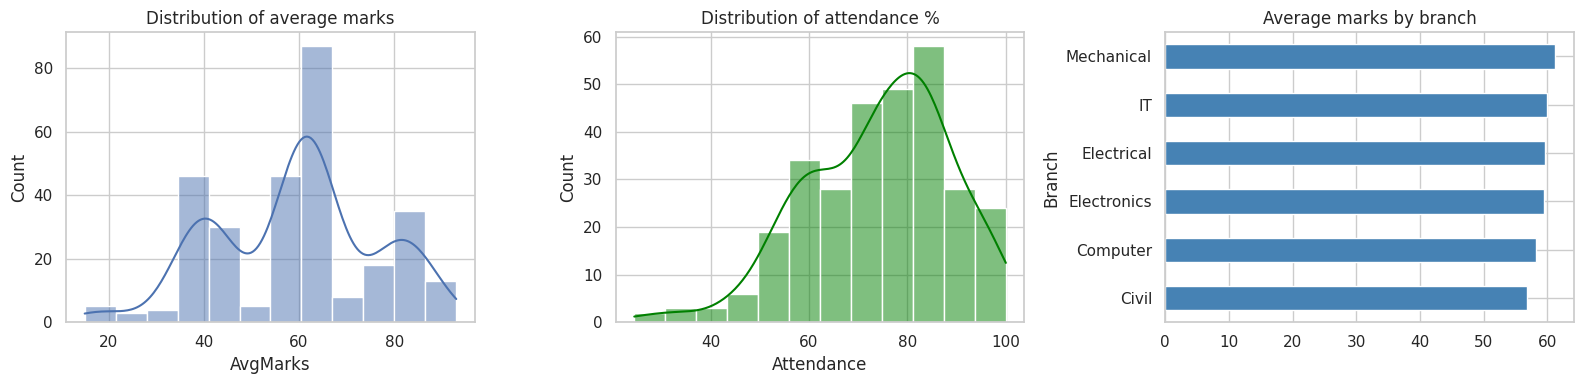

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["AvgMarks"], kde=True, ax=ax[0])
ax[0].set_title("Distribution of average marks")
sns.histplot(df["Attendance"], kde=True, ax=ax[1], color="green")
ax[1].set_title("Distribution of attendance %")
df.groupby("Branch")["AvgMarks"].mean().sort_values().plot(kind="barh", ax=ax[2], color="steelblue")
ax[2].set_title("Average marks by branch")
plt.tight_layout()
plt.show()

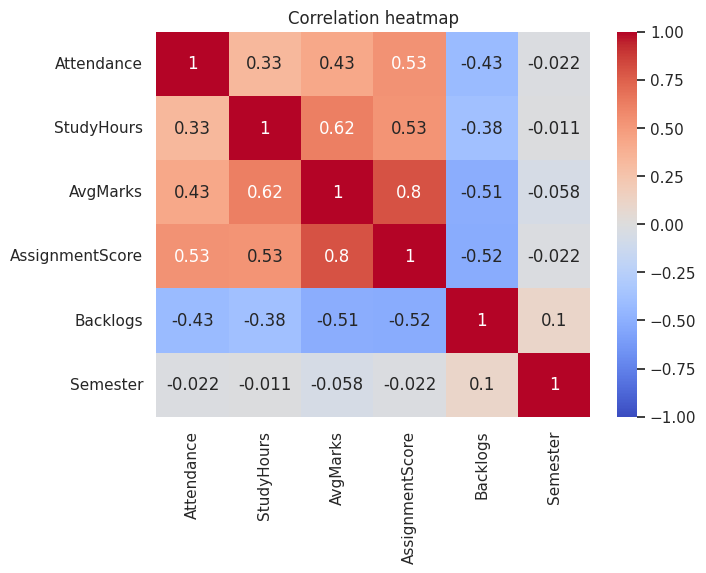

In [14]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[["Attendance", "StudyHours", "AvgMarks", "AssignmentScore", "Backlogs", "Semester"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.show()

## 5. Beyond syllabus: DBSCAN

min_samples = 8, eps = 0.93


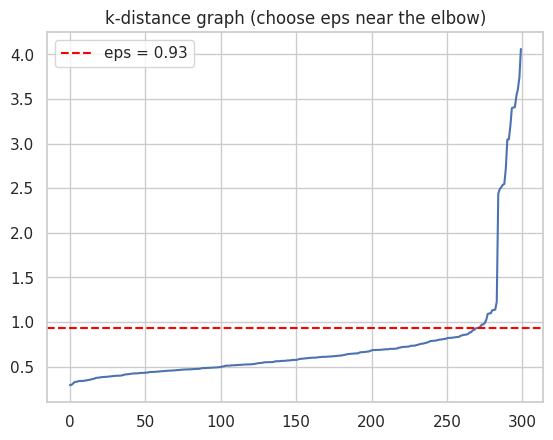

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import cdist

features = ["Attendance", "AvgMarks", "StudyHours", "AssignmentScore"]
X = StandardScaler().fit_transform(df[features])
min_samples = 2 * len(features)

# distance of every student to its 8th nearest neighbour, sorted
distances, _ = NearestNeighbors(n_neighbors=min_samples + 1).fit(X).kneighbors(X)
kd = np.sort(distances[:, -1])
eps = round(float(np.percentile(kd, 90)), 2)
print(f"min_samples = {min_samples}, eps = {eps}")

plt.plot(kd)
plt.axhline(eps, color="red", ls="--", label=f"eps = {eps}")
plt.title("k-distance graph (choose eps near the elbow)")
plt.legend()
plt.show()

In [18]:
model = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
labels = model.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = labels == -1
core = np.zeros(len(X), bool); core[model.core_sample_indices_] = True
print(f"DBSCAN found {n_clusters} clusters and {noise.sum()} noise students ({noise.mean():.1%})")
print("Point types ->", {"core": int(core.sum()), "border": int((~core & ~noise).sum()), "noise": int(noise.sum())})
if n_clusters >= 2:
    print(f"Silhouette (excluding noise): {silhouette_score(X[~noise], labels[~noise]):.3f}")

df["DBSCAN_label"] = labels
prof = df.assign(Group=np.where(noise, "Noise", labels)).groupby("Group")[features + ["Backlogs"]].mean().round(1)
prof.insert(0, "Students", df.assign(Group=np.where(noise, "Noise", labels)).groupby("Group").size())
display(prof)

DBSCAN found 2 clusters and 16 noise students (5.3%)
Point types -> {'core': 273, 'border': 11, 'noise': 16}
Silhouette (excluding noise): 0.522


,Students,Attendance,AvgMarks,StudyHours,AssignmentScore,Backlogs
Group,,,,,,
0,203,81.2,67.3,2.4,73.4,0.3
1,81,58.3,40.1,1.1,44.5,1.7
Noise,16,65.6,53.5,4.2,52.6,0.2


### Naming the groups

In [19]:
order = df[~noise].groupby("DBSCAN_label")["AvgMarks"].mean().sort_values(ascending=False).index.tolist()
if len(order) == 3:
    names = ["High performers", "Average", "Needs support"]
elif len(order) == 2:
    names = ["Better performing", "Needs support"]
else:
    names = [f"Group {i + 1}" for i in range(len(order))]
mapping = {lab: names[i] for i, lab in enumerate(order)}

def noise_reason(r):
    if r.Attendance < 60 and r.AvgMarks >= 70:
        return "Unusual: good marks but very low attendance"
    if r.Attendance >= 85 and r.AvgMarks < 45:
        return "Unusual: regular attendance but very low marks"
    return "Unusual profile"

df["Group"] = df["DBSCAN_label"].map(mapping)
df.loc[noise, "Group"] = df[noise].apply(noise_reason, axis=1)
display(df["Group"].value_counts().to_frame("students"))

if injected_ids:
    caught = df[noise & df["StudentID"].isin(injected_ids)].shape[0]
    print(f"Validation: DBSCAN flagged {caught} of the {len(injected_ids)} deliberately unusual students as noise")

,students
Group,
Better performing,203
Needs support,81
Unusual: regular attendance but very low marks,8
Unusual: good marks but very low attendance,8


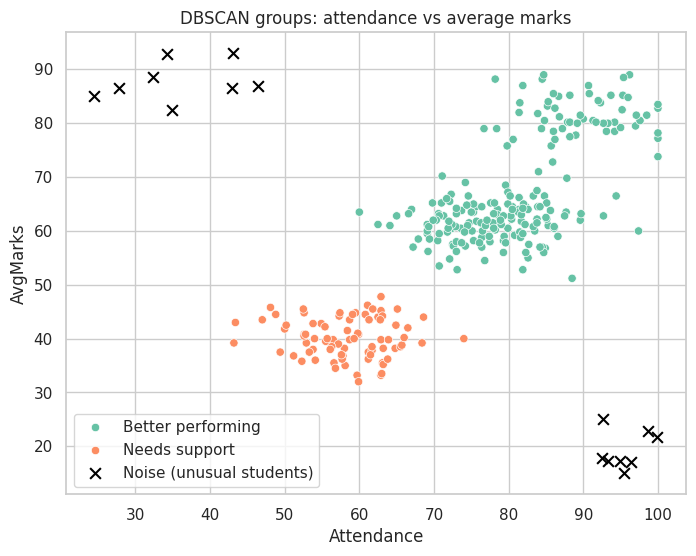

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df[~noise], x="Attendance", y="AvgMarks", hue="Group", palette="Set2")
plt.scatter(df.loc[noise, "Attendance"], df.loc[noise, "AvgMarks"],
            c="black", marker="x", s=60, label="Noise (unusual students)")
plt.title("DBSCAN groups: attendance vs average marks")
plt.legend()
plt.show()

### DBSCAN from scratch

In [21]:
def dbscan_scratch(X, eps, min_samples):
    D = cdist(X, X)
    neighbours = [np.where(D[i] <= eps)[0] for i in range(len(X))]
    labels = np.full(len(X), -1)
    cluster = 0
    for i in range(len(X)):
        if labels[i] != -1 or len(neighbours[i]) < min_samples:
            continue
        labels[i] = cluster
        queue = list(neighbours[i])
        while queue:
            j = queue.pop()
            if labels[j] == -1:
                labels[j] = cluster
                if len(neighbours[j]) >= min_samples:
                    queue.extend(neighbours[j])
        cluster += 1
    return labels

scratch = dbscan_scratch(X, eps, min_samples)
print("Agreement with scikit-learn (Adjusted Rand):", round(adjusted_rand_score(labels, scratch), 3))

Agreement with scikit-learn (Adjusted Rand): 1.0


## 6. Connect the results back to the Student Management System

In [22]:
for sid, grp in zip(df["StudentID"], df["Group"]):
    sms.update_student(int(sid), Cluster=grp)

def students_needing_attention():
    return sms.all_students("Cluster LIKE 'Needs%' OR Cluster LIKE 'Unusual%'")[
        ["StudentID", "Name", "Branch", "Attendance", "Python", "DataScience", "Maths", "DBMS", "Cluster"]]

def advice(sid):
    g = sms.get_student(sid).Cluster
    tips = {"High performers": "Encourage mentoring / advanced projects.",
            "Better performing": "Encourage mentoring and regular practice tests to keep improving.",
            "Average": "Regular practice tests to move to the next level.",
            "Needs support": "Extra classes, attendance follow-up and a study plan."}
    if g in tips:
        return tips[g]
    return "Meet the student: " + str(g).replace("Unusual: ", "") + "."

need = students_needing_attention()
print(f"{len(need)} students need attention:")
display(need.head(10))

sid = int(df[noise]["StudentID"].iloc[0])
sms.report_card(sid)
print("Advice:", advice(sid))

97 students need attention:


,StudentID,Name,Branch,Attendance,Python,DataScience,Maths,DBMS,Cluster
0,1006,Riya Mehta,IT,56.6,20.0,37.0,42.0,43.0,Needs support
1,1007,Om Gandhi,Mechanical,59.5,32.0,50.0,52.0,45.0,Needs support
2,1011,Meera Patel,Electronics,48.8,50.0,44.0,46.0,38.0,Needs support
3,1012,Kavya Shah,Electronics,94.9,25.0,10.0,9.0,25.0,Unusual: regular attendance but very low marks
4,1014,Diya Desai,Electronics,52.6,41.0,32.0,45.0,61.0,Needs support
5,1016,Om Joshi,Electrical,58.0,33.0,40.0,41.0,39.0,Needs support
6,1032,Riya Joshi,Civil,61.2,43.0,41.0,30.0,36.0,Needs support
7,1033,Arjun Vora,Civil,54.9,47.0,45.0,39.0,40.0,Needs support
8,1036,Harsh Parekh,IT,56.2,41.0,38.0,49.0,29.0,Needs support
9,1039,Tanvi Parekh,Mechanical,63.1,25.0,37.0,36.0,44.0,Needs support


REPORT CARD | ID 1012 | Kavya Shah | Electronics, Semester 5
  Python         25
  DataScience    10
  Maths           9
  DBMS           25
  Average      17.2
  Attendance 94.9% | Backlogs 0 | Group: Unusual: regular attendance but very low marks
Advice: Meet the student: regular attendance but very low marks.


## 7. Export results

In [23]:
df.to_csv("students_with_groups.csv", index=False)
need.to_csv("students_needing_attention.csv", index=False)
print("Saved: students_with_groups.csv, students_needing_attention.csv")
try:
    from google.colab import files
    files.download("students_with_groups.csv")
except ImportError:
    print("(Not in Colab - files are in the working folder)")

Saved: students_with_groups.csv, students_needing_attention.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>